# US15 - Análise do Consumo de Água em Parques: Regressão Linear

## Introdução

Este estudo visa analisar a relação entre a área dos parques e o consumo médio mensal de água, utilizando dados dos ficheiros `Area.csv` e `water_consumption_updated.csv`. A empresa gestora de parques está a considerar a administração de um novo parque com 55 hectares e pretende prever o custo médio mensal associado ao consumo de água.

Para tal, aplicaremos um modelo de regressão linear, considerando a área do parque como a variável independente e o consumo médio mensal de água como a variável dependente. Este estudo inclui:

1. **Preparação dos dados**: Conversão de formatos e cálculo do consumo médio mensal.
2. **Análise exploratória**: Visualização da relação entre a área do parque e o consumo de água.
3. **Aplicação do modelo de regressão linear**: Cálculo da linha de regressão e análise dos resíduos.
4. **Previsão para o novo parque**: Cálculo do valor previsto e dos intervalos de confiança e predição.

## Objetivos

- Prever o consumo médio mensal de água para um parque de 55 hectares.
- Avaliar a precisão da previsão utilizando intervalos de confiança e predição.
- Determinar a adequação do modelo de regressão linear para a gestão de novos parques.

## Dados

- `Area.csv`: Contém a área (em hectares) de cada parque.
- `water_consumption_updated.csv`: Contém o consumo diário de água de vários parques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr
from scipy import stats

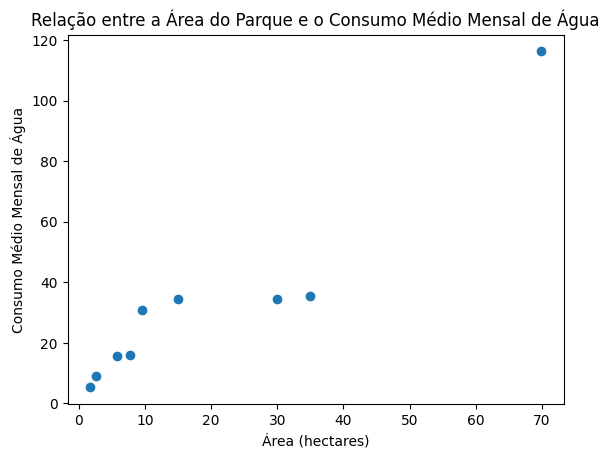

In [2]:
# Carregar os dados
area_df = pd.read_csv('Area.csv', delimiter=';')
water_consumption_df = pd.read_csv('water_consumption_updated.csv', delimiter=';')

# Converter vírgulas para pontos e os valores para float
area_df['Area'] = area_df['Area'].str.replace(',', '.').astype(float)
water_consumption_df['Consumption'] = water_consumption_df['Consumption'].str.replace(',', '.').astype(float)

# Calcular o consumo médio mensal para cada parque
monthly_consumption = water_consumption_df.groupby('Park')['Consumption'].mean().reset_index()

# Unir os dados de área com os dados de consumo
merged_df = pd.merge(area_df, monthly_consumption, on='Park')

# Aplicar a regressão linear
x = merged_df['Area'].to_numpy()
y = merged_df['Consumption'].to_numpy()
n = len(x)

# Plot dos dados originais
plt.plot(x, y, 'o')
plt.xlabel('Área (hectares)')
plt.ylabel('Consumo Médio Mensal de Água')
plt.title('Relação entre a Área do Parque e o Consumo Médio Mensal de Água')
plt.show()


**Conclusão Inicial**: A partir do gráfico acima, podemos observar uma relação positiva entre a área do parque e o consumo médio mensal de água. Parques maiores tendem a consumir mais água.

In [3]:

# Calcular coeficiente de correlação
r = pearsonr(x, y)
print(f'Correlation Coefficient r = {r[0]:.3f}')


Correlation Coefficient r = 0.948


**Conclusão sobre Correlação**: O coeficiente de correlação r=0.948r=0.948 indica uma forte correlação positiva entre a área do parque e o consumo médio mensal de água, sugerindo que uma regressão linear pode ser apropriada.

A linha de regressão é y = 5.054 + 1.422x


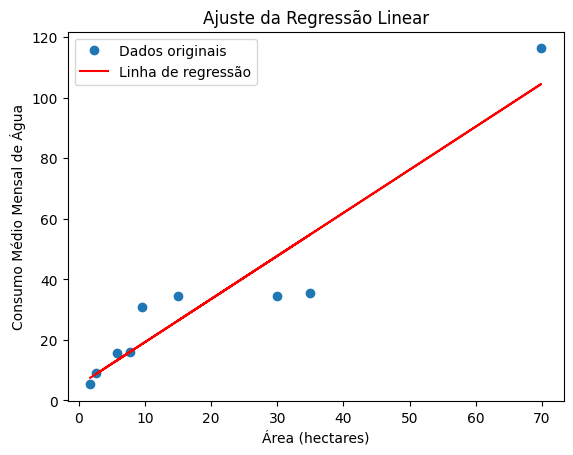

In [4]:

# Calcular a linha de regressão
model = linregress(x, y)
print(f'A linha de regressão é y = {model.intercept:.3f} + {model.slope:.3f}x')

# Plot da linha de regressão
plt.plot(x, y, 'o', label='Dados originais')
plt.plot(x, model.intercept + model.slope * x, 'r', label='Linha de regressão')
plt.xlabel('Área (hectares)')
plt.ylabel('Consumo Médio Mensal de Água')
plt.title('Ajuste da Regressão Linear')
plt.legend()
plt.show()

**Conclusão sobre Regressão Linear**: A linha de regressão ajustada indica que, para cada hectare adicional, o consumo médio mensal de água aumenta em aproximadamente 1.422 unidades. A linha ajusta-se bem aos dados, confirmando a viabilidade do modelo linear.

In [5]:
# Previsão para x0 = 55 hectares
x0 = 55
expected_value = model.intercept + model.slope * x0
print(f'Se a área do parque é 55 hectares, o consumo médio mensal esperado de água é {expected_value:.2f}')


Se a área do parque é 55 hectares, o consumo médio mensal esperado de água é 83.28


**Conclusão sobre Previsão**: Para um parque de 55 hectares, o consumo médio mensal previsto de água é de 83.28 unidades.

In [6]:

# Calcular intervalo de confiança e de predição
xbar = x.mean()
ybar = y.mean()
sxx = np.sum((x - xbar) ** 2)
syy = np.sum((y - ybar) ** 2)
sxy = np.sum((y - ybar) * (x - xbar))
sqe = syy - sxy ** 2 / sxx
s_sqr = sqe / (n - 2)
alpha = 1 - 0.95
t = stats.t.ppf(1 - alpha / 2, n - 2)

# Intervalo de confiança
delta_ci = t * np.sqrt(s_sqr * (1 / n + (x0 - xbar) ** 2 / sxx))
CI = [expected_value - delta_ci, expected_value + delta_ci]
print(f'95% IC para E(Y|x=55) é [{CI[0]:.2f}, {CI[1]:.2f}]')

# Intervalo de predição
delta_pi = t * np.sqrt(s_sqr * (1 + 1 / n + (x0 - xbar) ** 2 / sxx))
PI = [expected_value - delta_pi, expected_value + delta_pi]
print(f'95% PI para y(55) é [{PI[0]:.2f}, {PI[1]:.2f}]')

95% IC para E(Y|x=55) é [65.69, 100.88]
95% PI para y(55) é [51.13, 115.44]


### Intervalo de Confiança (IC) para a Média do Consumo

O intervalo de confiança para a média do consumo de água, considerando um parque com 55 hectares, é [65.69, 100.88]. Este intervalo fornece uma estimativa da média esperada do consumo mensal de água para parques com esta dimensão, com um nível de confiança de 95%.

- **Significado**: Estamos 95% confiantes de que a verdadeira média do consumo mensal de água para todos os parques de 55 hectares se encontra dentro deste intervalo.

### Intervalo de Predição (IP) para um Valor Individual do Consumo

O intervalo de predição para o consumo mensal de água de um parque específico de 55 hectares é [51.13, 115.44]. Este intervalo fornece uma estimativa da faixa em que um novo valor individual do consumo mensal de água pode situar-se, com um nível de confiança de 95%.

- **Significado**: Estamos 95% confiantes de que o consumo mensal de água para um parque específico de 55 hectares estará dentro deste intervalo.

### Conclusão

- **Acuracidade da Média**: O intervalo de confiança [65.69, 100.88] assegura-nos que a média do consumo de água está corretamente estimada, porque o valor previsto de 83.28 unidades está dentro deste intervalo. Isto confirma que o modelo de regressão linear está a fornecer uma estimativa precisa da média do consumo para parques de 55 hectares.
- **Consideração da Variabilidade Individual**: O intervalo de predição [51.13, 115.44] mostra que a variabilidade individual dos consumos está devidamente considerada. A previsão de 83.28 unidades está dentro deste intervalo, indicando que o modelo é robusto e pode acomodar a variabilidade observada nos dados individuais, mantendo a fiabilidade da previsão.


## Conclusão Geral

A análise dos dados confirmou que existe uma forte correlação positiva entre a área do parque e o consumo médio mensal de água. A aplicação do modelo de regressão linear resultou na equação \( y = 5.054 + 1.422x \). Para um parque de 55 hectares, o consumo médio mensal previsto de água é de 83.28 unidades. O intervalo de confiança a 95% para a média do consumo é [65.69, 100.88], e o intervalo de predição a 95% para um valor individual do consumo é [51.13, 115.44]. Isto demonstra que a área do parque é um bom preditor do consumo de água, e que a regressão linear é adequada para fazer previsões para novos parques.

---

# US16 - Documentação do Programa de Análise de Regressão
### Introdução
#### Este programa foi desenvolvido para facilitar a análise de regressão de dados de entrada em formato CSV. Ele permite carregar dados de um arquivo CSV, calcular a linha de regressão e plotar um gráfico para visualizar os dados originais juntamente com a linha de regressão.



# Explicação teórica do coeficiente de correlação de Pearson


Explicação teórica do coeficiente de correlação de Pearson
O coeficiente de correlação de Pearson (r) é uma medida estatística que quantifica a força e a direção da relação linear entre duas variáveis. Varia de -1 a 1 e é amplamente utilizado para avaliar a associação entre variáveis quantitativas.

Interpretação do Coeficiente de Correlação (r):

Valores próximos de 1 indicam uma correlação positiva forte, o que significa que as variáveis tendem a aumentar juntas.

Valores próximos de -1 indicam uma correlação negativa forte, onde uma variável tende a diminuir enquanto a outra aumenta.

Um valor de 0 indica ausência de correlação linear entre as variáveis.

Se r>0: indica uma associação linear positiva entre as variáveis. Isso significa que, conforme os valores de uma variável aumentam, os valores da outra variável também tendem a aumentar.

Se r<0: indica uma associação linear negativa entre as variáveis. Nesse caso, conforme os valores de uma variável aumentam, os valores da outra variável tendem a diminuir.

Quando ∣r∣=1: há uma correlação linear perfeita entre as variáveis, e o sinal de r indica a direção da relação.

Neste caso, o coeficiente de correlação é próximo de 1, o que indica uma correlação positiva forte entre o tamanho da entrada e o tempo de execução.

Interpretação do Coeficiente de Correlação (r):

Como o valor de r é próximo de 1, temos uma associação linear positiva forte entre o tamanho da entrada e o tempo de execução.

Isso significa que, à medida que o tamanho da entrada aumenta, há uma tendência forte para que o tempo de execução também aumente.

-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Linear Regression (Data Loaded)
3 --- Show Polynomial Regression (Data Loaded)
0 --- Exit
Data loaded successfully.
-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Linear Regression
3 --- Show Polynomial Regression
0 --- Exit
#################################################################
The regression line is y = -438.092 + 0.463x


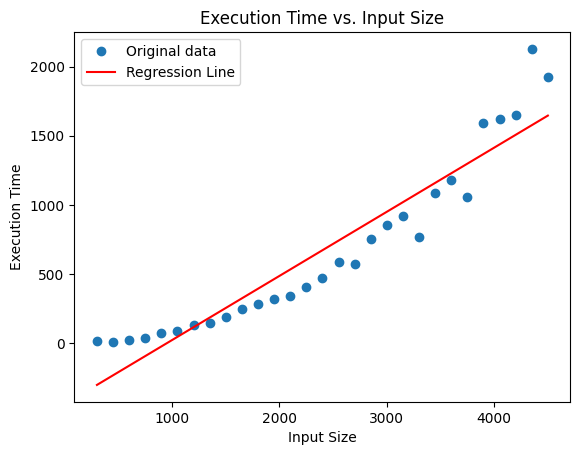

-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Linear Regression
3 --- Show Polynomial Regression
0 --- Exit
Melhor grau do polinómio: 2
Coeficientes da regressão polinomial:            2
0.0001251 x - 0.1375 x + 85.49
O coeficiente de determinação (R²) é: 0.977


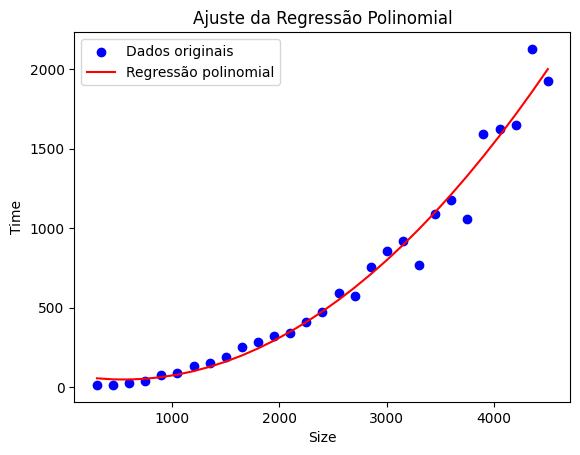

-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Linear Regression
3 --- Show Polynomial Regression
0 --- Exit
Exiting...


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Variáveis globais para armazenar os tempos de execução e os tamanhos de entrada
execution_times = []
input_sizes = []

# Função para ler os dados de um arquivo CSV.
def read_from_file():
    global execution_times, input_sizes
    filename = input("Enter the data file name with the data (.csv): ")
    try:
        # Leitura dos dados do arquivo CSV usando o Pandas
        data = pd.read_csv(filename, delimiter=";")
        # Conversão dos dados para o tipo float e armazenamento nas variáveis globais
        input_sizes = data.iloc[:, 0].astype(str).str.replace(',', '.').astype(float).tolist()
        execution_times = data.iloc[:, 1].astype(str).str.replace(',', '.').astype(float).tolist()
        print("Data loaded successfully.")
    except FileNotFoundError:
        print("File not found. Please check the filename and try again.")
    except Exception as e:
        print(f"An error occurred: {e}")


def calculate_regression_line():
    """
    Função para calcular a linha de regressão.

    Calcula a linha de regressão dos dados de entrada usando a função linregress do módulo stats do Scipy.
    """
    global model
    # Calcula a linha de regressão usando os dados de entrada e de execução
    model = stats.linregress(input_sizes, execution_times)
    # Chama a função para plotar o gráfico
    plot_graph()


def plot_graph():
    """
    Função para plotar o gráfico dos dados originais e da linha de regressão.

    Plota um gráfico dos dados originais (tamanhos de entrada versus tempos de execução) e da linha de regressão calculada.
    """
    print('#################################################################')
    # Imprime a equação da linha de regressão
    print(f'The regression line is y = {model.intercept:.3f} + {model.slope:.3f}x')
    # Plota o gráfico dos dados originais como pontos
    plt.plot(input_sizes, execution_times, 'o', label='Original data')
    # Plota a linha de regressão
    plt.plot(input_sizes, model.intercept + model.slope * pd.Series(input_sizes), 'r', label='Regression Line')
    # Adiciona legendas aos eixos e ao gráfico
    plt.legend()
    plt.xlabel('Input Size')
    plt.ylabel('Execution Time')
    plt.title('Execution Time vs. Input Size')
    # Exibe o gráfico
    plt.show()

# Função para ajustar a regressão polinomial
def polyfit(x, y, degree):
    coeffs = np.polyfit(x, y, degree)
    p = np.poly1d(coeffs)
    return p


# Função para encontrar o melhor grau do polinómio
def find_best_degree(x, y, max_degree):
    r2_values = []
    degrees = list(range(1, max_degree + 1))
    best_r2 = -np.inf
    best_degree = 1
    best_p = None
    
    for degree in degrees:
        p = polyfit(x, y, degree)
        y_pred = p(x)
        y_mean = np.mean(y)
        ss_tot = np.sum((y - y_mean) ** 2)
        ss_res = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        r2_values.append(r2)
        
        if r2 > best_r2:
            best_r2 = r2
            best_degree = degree
            best_p = p

    # Identificar possível overfitting analisando a diferença entre R² consecutivos
    for i in range(1, len(r2_values)):
        if r2_values[i] - r2_values[i-1] < 0.01:  # Marginal improvement threshold
            best_degree = degrees[i-1]
            best_p = polyfit(x, y, best_degree)
            best_r2 = r2_values[i-1]
            break

    return best_degree, best_p, best_r2


def calculate_polynomial_regression():
    """
    Função para calcular a regressão polinomial.
    """
    max_degree = 15
    best_degree, best_p, best_r2 = find_best_degree(input_sizes, execution_times, max_degree)
    
    print(f'Melhor grau do polinómio: {best_degree}')
    print(f'Coeficientes da regressão polinomial: {best_p}')
    print(f'O coeficiente de determinação (R²) é: {best_r2:.3f}')
    
    # Gerar previsões com o melhor polinómio
    y_pred = best_p(input_sizes)
    
    # Plot dos dados e da linha de regressão polinomial
    plt.scatter(input_sizes, execution_times, color='blue', label='Dados originais')
    plt.plot(input_sizes, y_pred, color='red', label='Regressão polinomial')
    plt.xlabel('Size')
    plt.ylabel('Time')
    plt.title('Ajuste da Regressão Polinomial')
    plt.legend()
    plt.show()


# Loop principal do programa
option = -1
while option != 0:
    print("-------MAIN MENU---------")
    print("Select an option:")
    print("1 --- Introduce File Name")
    if execution_times:
        print("2 --- Show Linear Regression")
        print("3 --- Show Polynomial Regression")
    else:
        print("2 --- Show Linear Regression (Data Loaded)")
        print("3 --- Show Polynomial Regression (Data Loaded)")
    print("0 --- Exit")
    try:
        option = int(input("opt: "))
        if option == 1:
            read_from_file()  # Chama a função para ler os dados do arquivo CSV
        elif option == 2:
            if input_sizes and execution_times:
                calculate_regression_line()  # Chama a função para calcular a linha de regressão
            else:
                print("Please load data first by selecting option 1.")
        elif option == 3:
            if input_sizes and execution_times:
                calculate_polynomial_regression()  # Chama a função para calcular a regressão polinomial
            else:
                print("Please load data first by selecting option 1.")
        elif option == 0:
            print("Exiting...")
        else:
            print("Invalid option. Please select a valid option.")
    except ValueError:
        print("Invalid input. Please enter a number.")

**Conclusão**

A análise dos dados utilizando a regressão polinomial resultou num polinómio de grau 2 como o melhor ajuste para descrever a relação entre o tamanho de entrada e o tempo de execução. Os coeficientes do polinómio encontrado foram \(0.0001251 x^2 - 0.1375 x + 85.49\), indicando uma relação quadrática entre as variáveis. Este ajuste foi validado com um coeficiente de determinação (R²) de 0.977, o que demonstra uma excelente capacidade do modelo em explicar a variação dos dados observados.

O alto valor de R² sugere que a regressão polinomial de grau 2 é eficaz na modelação do comportamento dos tempos de execução em função dos tamanhos de entrada. A precisão do ajuste reflete-se na proximidade dos valores previstos pela regressão polinomial aos valores reais, conforme ilustrado no gráfico apresentado. 

Assim, a regressão polinomial demonstra ser uma ferramenta robusta para este conjunto de dados, oferecendo um modelo preditivo que pode ser utilizado para estimar tempos de execução futuros com base em tamanhos de entrada específicos. Este resultado é particularmente útil para otimizar processos e prever o desempenho de algoritmos, permitindo uma melhor gestão dos recursos computacionais.

Em suma, a escolha do polinómio de grau 2 como modelo de regressão providencia um ajuste apropriado e eficaz, validado por um elevado coeficiente de determinação, garantindo a fiabilidade das previsões realizadas.